In [1]:
import sys  
# sys.path.insert(1, 'D:/KINEPY/new 22.02.2025/kinepy-dev/kinepy-dev')
import kinepy as kp
import numpy as np
import matplotlib.pyplot as plt

https://www.desmos.com/calculator/ss2hbw4lfb?lang=fr

In [34]:
L = 7.55
N = 9
L_tot = N*L
Point_1 = np.array([np.linspace(-L_tot/2, L_tot/2, N+1), np.zeros(N+1)])
f = lambda x : 13.55 + 44.687*(1 - np.cosh(x/44.687))
x = np.linspace(-(N-1)*L / 2, (N-1)*L / 2, N)
Point_2 = np.array([x, f(x)])

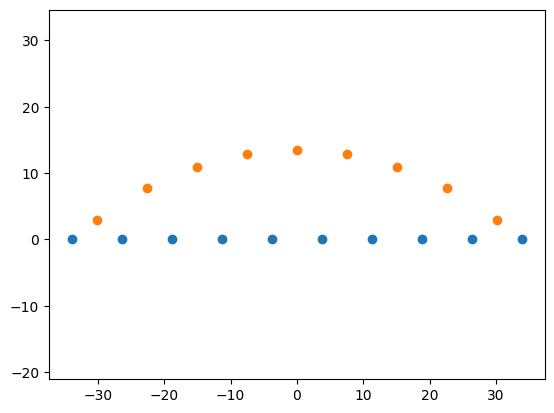

In [35]:
plt.plot(Point_1[0], Point_1[1], 'o')
plt.plot(Point_2[0], Point_2[1], 'o')
plt.axis('equal')
plt.show()

In [36]:
dist = lambda p1, p2 : np.linalg.norm(p1 - p2)
dd = np.linalg.norm

In [45]:
bridge = kp.System()

ground = bridge.ground


bottom_beams = []
top_revolute = []

g = L/2, 0
# bottom triangles
for triangle_index in range(N):
    b0 = bridge.add_solid(f'Bottom-{triangle_index}.Base', mass=1000, g=g)
    b1 = bridge.add_solid(f'Bottom-{triangle_index}.Left')
    b2 = bridge.add_solid(f'Bottom-{triangle_index}.Right')
    
    r0 = bridge.add_revolute(b0, b1)
    r1 = bridge.add_revolute(b0, b2, p1=(L, 0))

    v1, v2 = Point_1.swapaxes(0, 1)[triangle_index:][:2] - Point_2[:, triangle_index]
    r2 = bridge.add_revolute(b1, b2, p1=(dd(v1), 0), p2=(dd(v2), 0))
    
    bridge.declare_direct_triangle(r0, r1, r2)
    bottom_beams.append(b0)
    top_revolute.append(r2)

# top triangles
for triangle_index in range(N-1):
    b0 = bridge.add_solid(f'Top-{triangle_index}.Base')
    _r1, _r2 = top_revolute[triangle_index:][:2]
    b3, b4 = bottom_beams[triangle_index:][:2]
    
    r0 = bridge.add_revolute(b3, b4, p1=(L, 0))
    
    r1 = bridge.add_revolute(b0, _r1.s1, p2=_r1.p1)
    
    v1 = Point_2[:, triangle_index] - Point_2[:, triangle_index+1]
    r2 = bridge.add_revolute(b0, _r2.s2, p1=(dd(v1), 0), p2=_r2.p2)
    
    bridge.declare_direct_triangle(r0, r2, r1)

bridge.add_revolute(ground, bottom_beams[0])

# no need to make declarations about ps.sliding except if you want an upside-down bridge
ps = bridge.add_pin_slot(ground, bottom_beams[-1], p2=(L, 0))
bridge.declare_chose_lowest_value(ps.sliding)


bridge.add_gravity(g=(0, -10))
bridge.determine_computation_order()
n = 2
bridge.set_sim_parameters(n, 3)

In [46]:
# for config in bridge.get_steps_with_multiple_solutions()[::2]:
#     config.solution_index = 1
# bridge.get_steps_with_multiple_solutions()[-1].solution_index = 1

In [47]:
bridge.solve_kinematics()

In [48]:
kd = bridge.kinematic_diagram()
kd.show()

In [808]:
bridge.solve_dynamics()

In [811]:
r10.get_force()

KpArray([[0., 0.],
         [0., 0.]])